In [1]:
import os
from pathlib import Path
import sys

BASE_DIR = Path.cwd().parent
sys.path.append(str(BASE_DIR))

PROCESSED_DIR = BASE_DIR / "data"/ "processed"

processed_paths_dict = { 
    "beta": os.path.join(PROCESSED_DIR, "beta.parquet"),
    "mean_volatility": os.path.join(PROCESSED_DIR, "mean_volatility.parquet"),
    "microstructure": os.path.join(PROCESSED_DIR, "microstructure.parquet"),
    "momentum": os.path.join(PROCESSED_DIR, "momentum.parquet"),
    "momentum_liquidity": os.path.join(PROCESSED_DIR, "momentum_liquidity.parquet"),
    "pvo": os.path.join(PROCESSED_DIR, "pvo.parquet"), 
    "reversal": os.path.join(PROCESSED_DIR, "reversal.parquet"),
    "reversal_illiquidity": os.path.join(PROCESSED_DIR, "reversal_illiquidity.parquet")
}

In [2]:
BASE_DIR

WindowsPath('c:/Users/Gordon Li/Desktop/systematic_project')

In [3]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
import seaborn as sns

from scripts.research.ic import IC
from scripts.research.quintile import Quintile
from scripts.research.plots import (
    plot_ic_timeseries, 
    plot_ic_summary_bar, 
    plot_quintiles
)
from scripts.research.targets import ForwardReturns

## Forward Returns

In [4]:
returns_df = ForwardReturns([5, 10, 21]).run_data()

factors_df_dict = {}
for key, path in processed_paths_dict.items(): 
    factors_df_dict[key] = pd.read_parquet(path)

In [5]:
results_ic_dict, summary_ic_dict = dict(), dict()
results_quintile_dict, summary_quintile_dict = dict(), dict()
for factor, df in factors_df_dict.items(): 
    results_ic_dict[factor], summary_ic_dict[factor] = IC(returns_df, factors_df_dict[factor]).run_data()
    results_quintile_dict[factor], summary_quintile_dict[factor] = Quintile(returns_df, factors_df_dict[factor]).run_data()

## Beta

### Information Coefficient

In [6]:
beta_results_ic_dict, beta_summary_ic_df = results_ic_dict["beta"], summary_ic_dict["beta"]

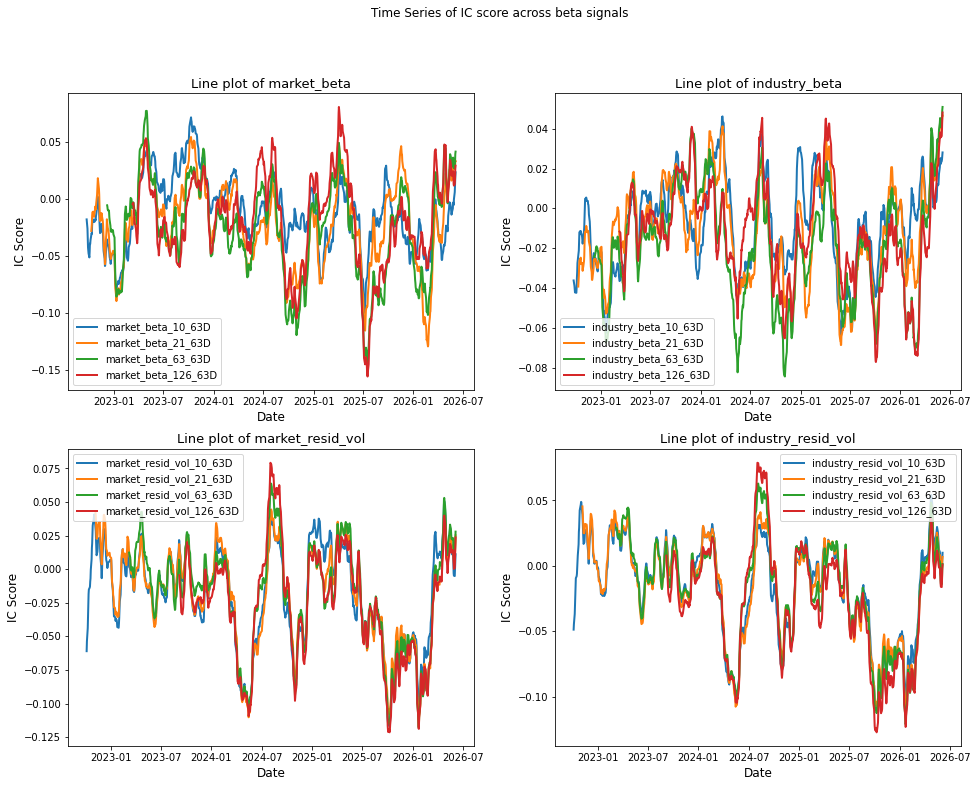

In [7]:
plot_ic_timeseries(beta_results_ic_dict, "beta")

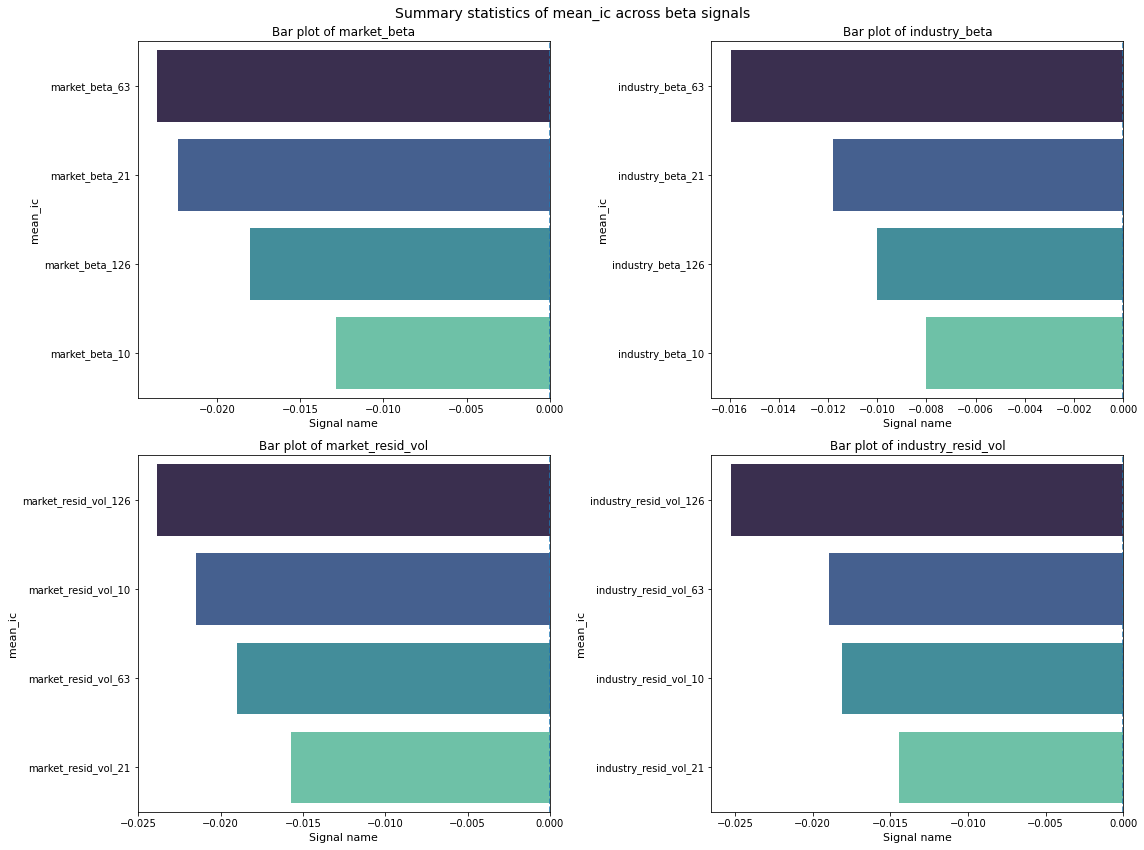

In [7]:
plot_ic_summary_bar(beta_results_ic_dict, beta_summary_ic_df, "beta", metric="mean_ic")

### Quintile Test

In [29]:
beta_results_quintile_dict, beta_summary_quintile_dict = results_quintile_dict["beta"], summary_quintile_dict["beta"]

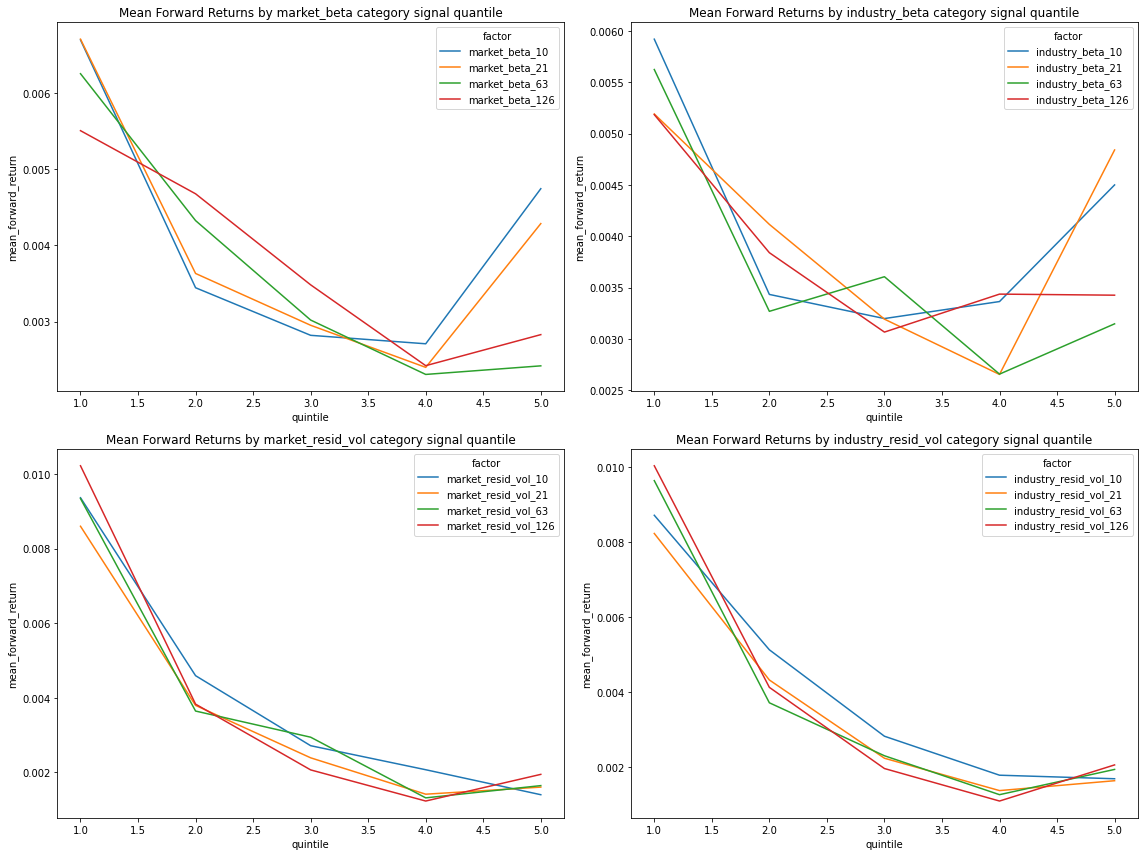

In [30]:
plot_quintiles(beta_results_quintile_dict, beta_summary_quintile_dict, "beta")

### Within family correlations

In [91]:
beta_factor_df = factors_df_dict["beta"]

market_beta_corr_df = beta_factor_df[["market_beta_10", "market_beta_21", "market_beta_63", "market_beta_126"]].corr("spearman")
industry_beta_corr_df = beta_factor_df[["industry_beta_10", "industry_beta_21", "industry_beta_63", "industry_beta_126"]].corr("spearman")
market_vol_corr_df = beta_factor_df[["market_resid_vol_10", "market_resid_vol_21", "market_resid_vol_63", "market_resid_vol_126"]].corr("spearman")
industry_vol_corr_df = beta_factor_df[["industry_resid_vol_10", "industry_resid_vol_21", "industry_resid_vol_63", "industry_resid_vol_126"]].corr("spearman")

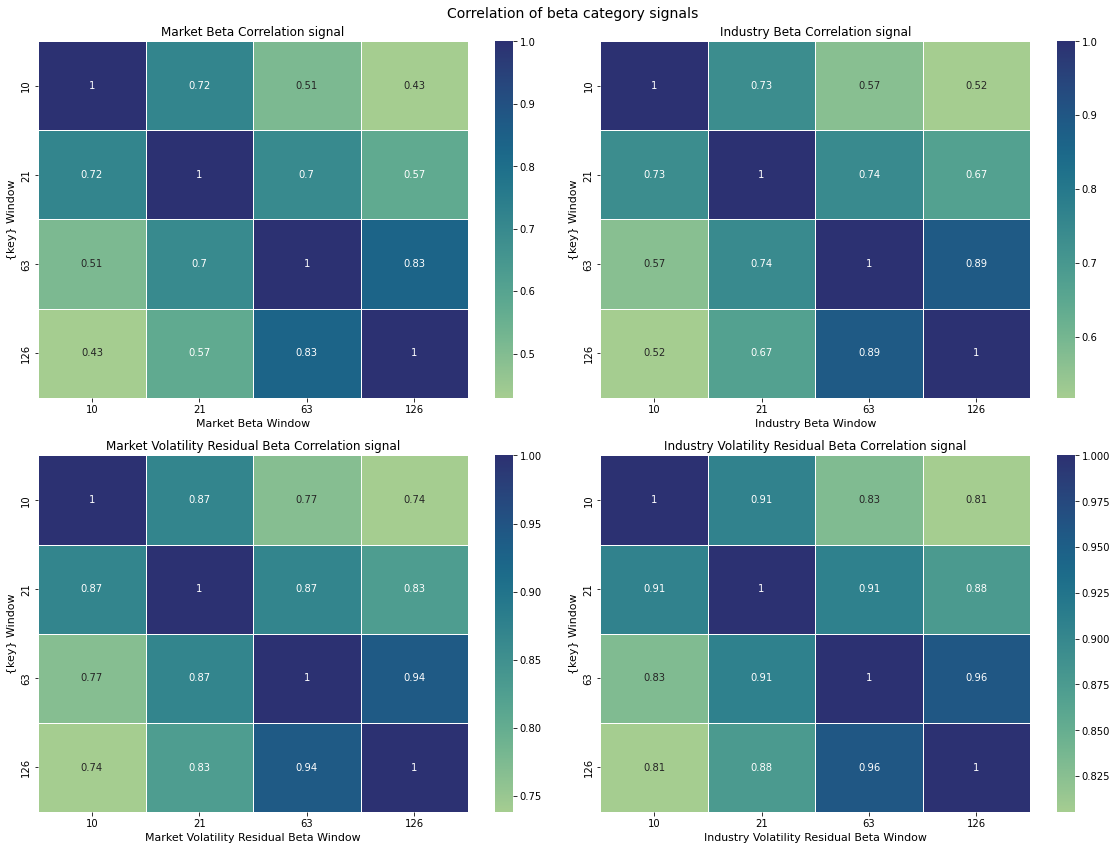

In [136]:
correlation_dfs_dict = {
    "Market Beta": market_beta_corr_df, 
    "Industry Beta": industry_beta_corr_df, 
    "Market Volatility Residual Beta": market_vol_corr_df, 
    "Industry Volatility Residual Beta": industry_vol_corr_df
}


fig, axs = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Correlation of beta category signals", fontsize=14)
axs = axs.ravel()
i = 0 
for key, df in correlation_dfs_dict.items(): 
    df.index = [x.split('_')[-1] for x in df.index]
    df.columns = [x.split('_')[-1] for x in df.columns]
    sns.heatmap(
        df, ax=axs[i], cmap="crest", annot=True, linewidths=1
    )
    axs[i].set_title(f"{key} Correlation signal", fontsize=12)
    axs[i].set_xlabel(f"{key} Window", fontsize=11)
    axs[i].set_ylabel("{key} Window", fontsize=11)
    i += 1
plt.tight_layout()
plt.show()

### Summary

In [32]:
valid_beta_factors = ["industry_resid_vol_26", "market_resid_vol_126", "market_beta_63", "industry_beta_63"]

## Mean Volatility

### Information Coefficient

In [8]:
mv_results_ic_dict, mv_summary_ic_df = results_ic_dict["mean_volatility"], summary_ic_dict["mean_volatility"]

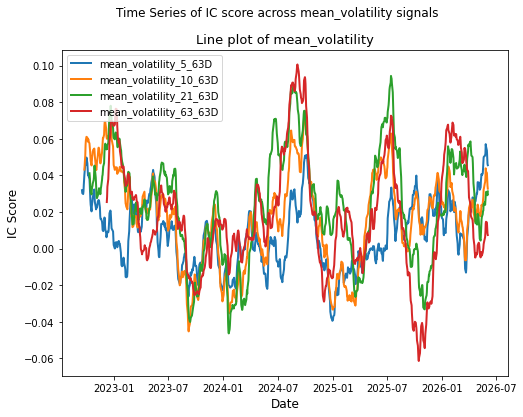

In [9]:
plot_ic_timeseries(mv_results_ic_dict, "mean_volatility")

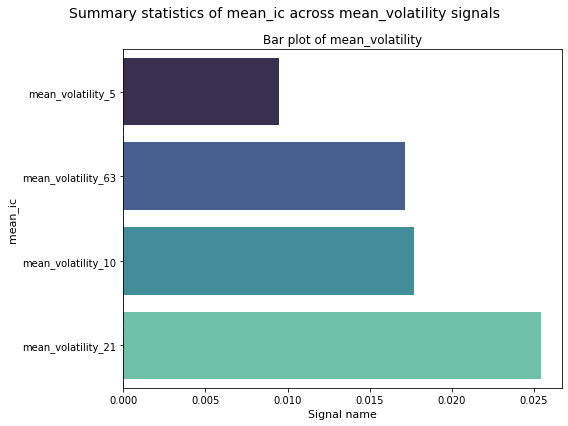

In [10]:
plot_ic_summary_bar(mv_results_ic_dict, mv_summary_ic_df, "mean_volatility", metric="mean_ic")

In [11]:
mv_results_quintile_dict, mv_summary_quintile_dict = results_quintile_dict["mean_volatility"], summary_quintile_dict["mean_volatility"]

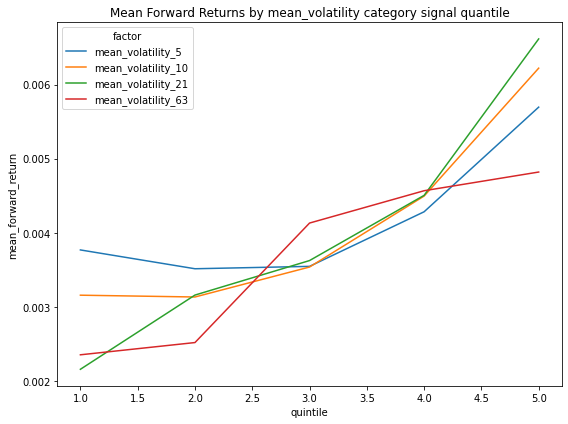

In [128]:
plot_quintiles(mv_results_quintile_dict, mv_summary_quintile_dict, "mean_volatility")

### Within family correlations

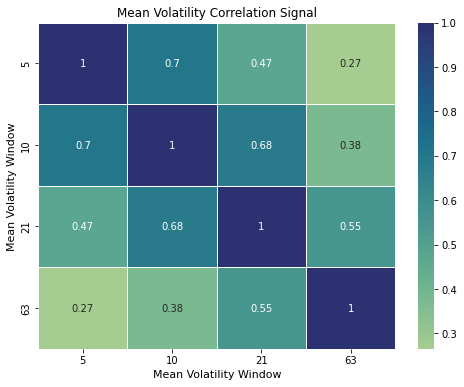

In [143]:
mv_df = factors_df_dict["mean_volatility"]
mv_corr_df = mv_df[mv_df.columns[2:]].corr("spearman")

mv_corr_df.index = [x.split('_')[-1] for x in mv_corr_df.index]
mv_corr_df.columns = [x.split('_')[-1] for x in mv_corr_df.columns]

plt.figure(figsize=(8, 6))
plt.title("Mean Volatility Correlation Signal", fontsize=12)
sns.heatmap(
    mv_corr_df, cmap="crest", annot=True, linewidths=1
)
plt.xlabel("Mean Volatility Window", fontsize=11)
plt.ylabel("Mean Volatility Window", fontsize=11)
plt.show()

## Microstructure

### Information Coefficient

In [146]:
microstructure_results_ic_dict, microstructure_summary_ic_df = results_ic_dict["microstructure"], summary_ic_dict["microstructure"]

In [148]:
microstructure_summary_ic_df

,dv_liquidity_21,dv_liquidity_63,dv_liquidity_126,amihud_21,amihud_63,amihud_126
mean_ic,-0.005294,-0.004635,-0.004831,-0.014862,-0.012691,-0.010887
std_ic,0.097905,0.097865,0.098002,0.117632,0.117947,0.116960
ic_ir,-0.054070,-0.047359,-0.049293,-0.126343,-0.107600,-0.093080
positive_ic_rate,0.479960,0.474923,0.473016,0.448345,0.446721,0.453390
n_periods,998.000000,977.000000,945.000000,997.000000,976.000000,944.000000


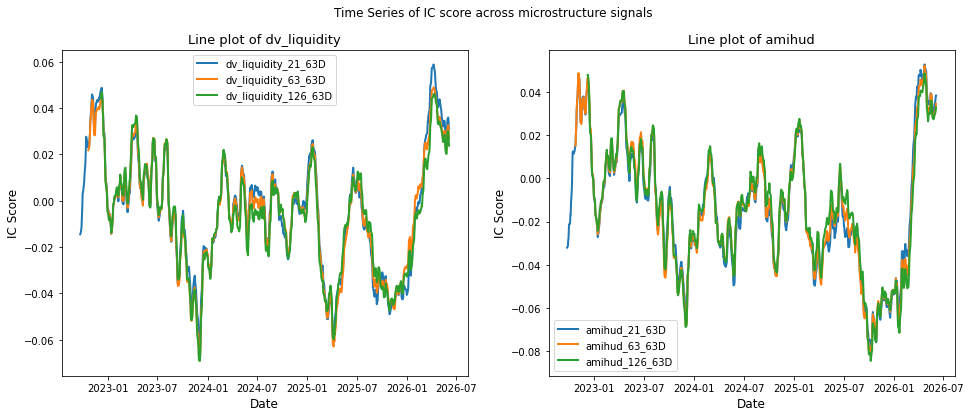

In [149]:
plot_ic_timeseries(microstructure_results_ic_dict, "microstructure")

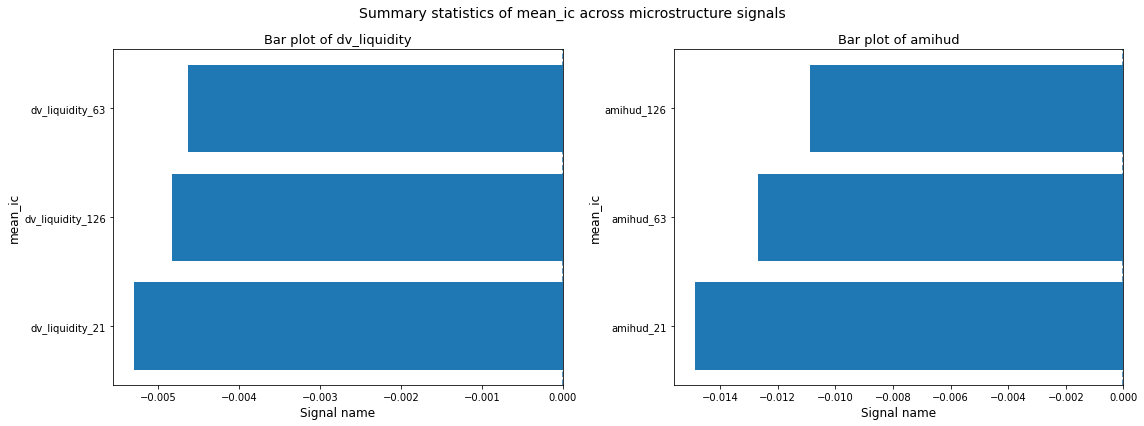

In [150]:
plot_ic_summary_bar(microstructure_results_ic_dict, microstructure_summary_ic_df, "microstructure", metric="mean_ic")

### Quintile Test

In [49]:
microstructure_results_quintile_dict, microstructure_summary_quintile_dict = results_quintile_dict["microstructure"], summary_quintile_dict["microstructure"]

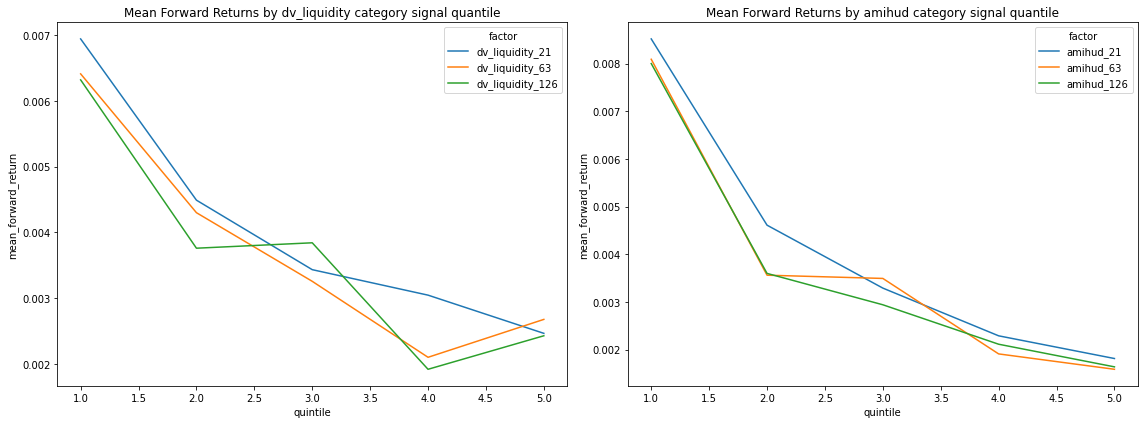

In [50]:
plot_quintiles(microstructure_results_quintile_dict, microstructure_summary_quintile_dict, "microstructure")

In [ ]:
correlation_dfs_dict = {
    "Reversal": rev_df_correlation, 
    "RSR": rsr_df_correlation
}


fig, axs = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Correlation of reversal category signals", fontsize=14)
axs = axs.ravel()
i = 0 
for key, df in correlation_dfs_dict.items(): 
    df.index = [x.split('_')[-1] for x in df.index]
    df.columns = [x.split('_')[-1] for x in df.columns]
    sns.heatmap(
        df, ax=axs[i], cmap="crest", annot=True, linewidths=1
    )
    axs[i].set_title(f"{key} Correlation signal", fontsize=12)
    axs[i].set_xlabel(f"{key} Window", fontsize=11)
    axs[i].set_ylabel(f"{key} Window", fontsize=11)
    i += 1
plt.tight_layout()
plt.show()

## Momentum

### Information Coefficient

In [46]:
momentum_results_ic_dict, momentum_summary_ic_df = results_ic_dict["momentum"], summary_ic_dict["momentum"]

In [48]:
momentum_results_ic_dict

{'momentum_252_12':           Date           factor            target        IC
 0   2023-07-13  momentum_252_12  future_return_5d  0.103917
 1   2023-07-14  momentum_252_12  future_return_5d -0.044674
 2   2023-07-17  momentum_252_12  future_return_5d -0.058165
 3   2023-07-18  momentum_252_12  future_return_5d -0.099966
 4   2023-07-19  momentum_252_12  future_return_5d -0.048475
 ..         ...              ...               ...       ...
 729 2026-05-29  momentum_252_12  future_return_5d -0.147502
 730 2026-06-01  momentum_252_12  future_return_5d -0.406495
 731 2026-06-02  momentum_252_12  future_return_5d -0.577662
 732 2026-06-03  momentum_252_12  future_return_5d -0.606574
 733 2026-06-04  momentum_252_12  future_return_5d -0.580313
 
 [734 rows x 4 columns],
 'id_252_12':           Date     factor            target        IC
 0   2023-07-13  id_252_12  future_return_5d -0.069685
 1   2023-07-14  id_252_12  future_return_5d  0.011435
 2   2023-07-17  id_252_12  future_return_5d

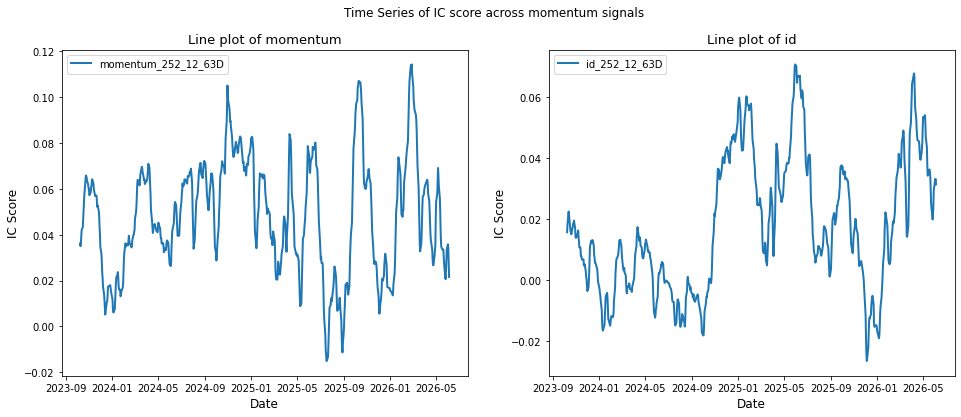

In [34]:
plot_ic_timeseries(momentum_results_ic_dict, "momentum")

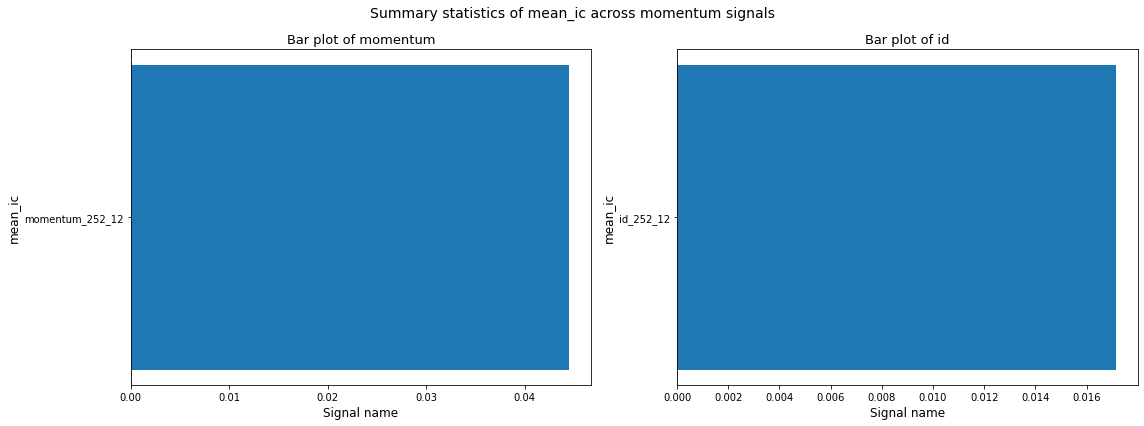

In [38]:
plot_ic_summary_bar(momentum_results_ic_dict, momentum_summary_ic_df, "momentum", metric="mean_ic")

In [40]:
momentum_results_quintile_dict, momentum_summary_quintile_dict = results_quintile_dict["momentum"], summary_quintile_dict["momentum"]

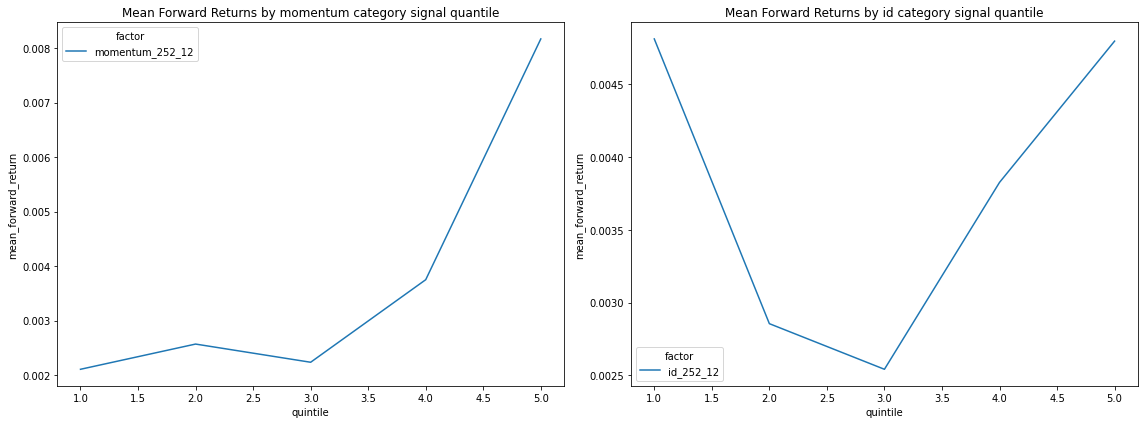

In [42]:
plot_quintiles(momentum_results_quintile_dict, momentum_summary_quintile_dict, "momentum")

In [43]:
momentum_quintile_10_dict, momentum_summary_quintile_10_df = Quintile(returns_df, factors_df_dict["momentum"], 10).run_data()

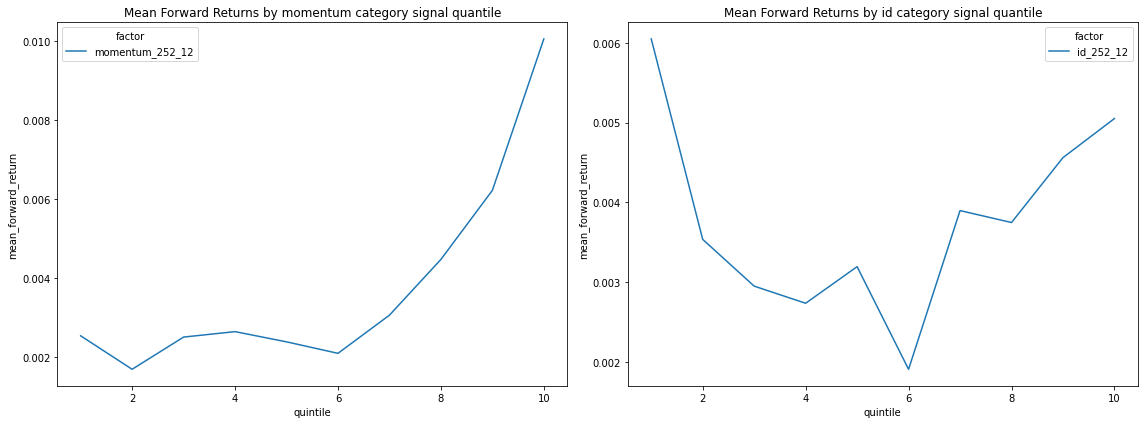

In [46]:
plot_quintiles(momentum_quintile_10_dict, momentum_summary_quintile_10_df, "momentum")

In [49]:
valid_momentum_factors = ["momentum_252_12"]

### Reversal

In [12]:
reversal_results_ic_dict, reversal_summary_ic_df = results_ic_dict["reversal"], summary_ic_dict["reversal"]

In [13]:
reversal_summary_ic_df

,reversal_5,reversal_10,reversal_21,rsr_5,rsr_10,rsr_21
mean_ic,0.023775,0.014680,0.015380,0.015893,0.016805,0.019927
std_ic,0.154832,0.159929,0.161706,0.116616,0.116223,0.119392
ic_ir,0.153553,0.091791,0.095111,0.136280,0.144597,0.166901
positive_ic_rate,0.567864,0.517553,0.530426,0.546906,0.566700,0.565923
n_periods,1002.000000,997.000000,986.000000,1002.000000,997.000000,986.000000


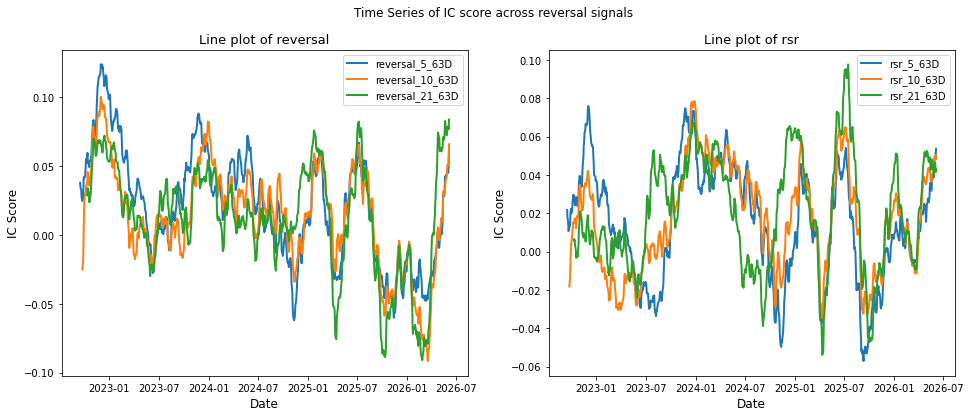

In [14]:
plot_ic_timeseries(reversal_results_ic_dict, "reversal")

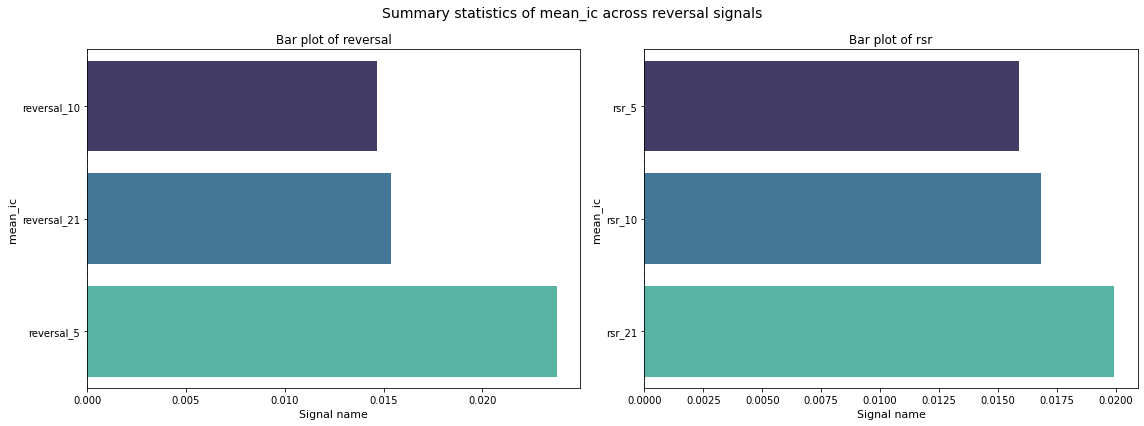

In [15]:
plot_ic_summary_bar(reversal_results_ic_dict, reversal_summary_ic_df, "reversal", metric="mean_ic")

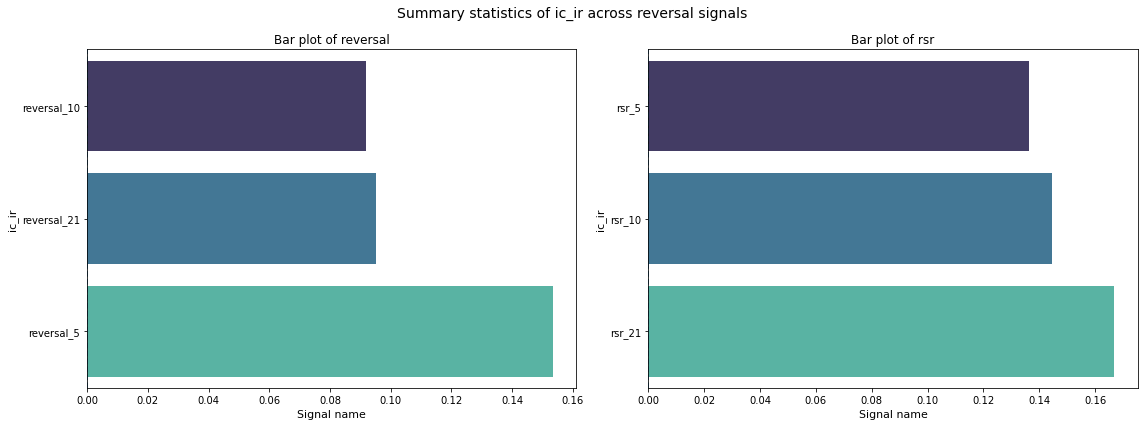

In [16]:
plot_ic_summary_bar(reversal_results_ic_dict, reversal_summary_ic_df, "reversal", metric="ic_ir")

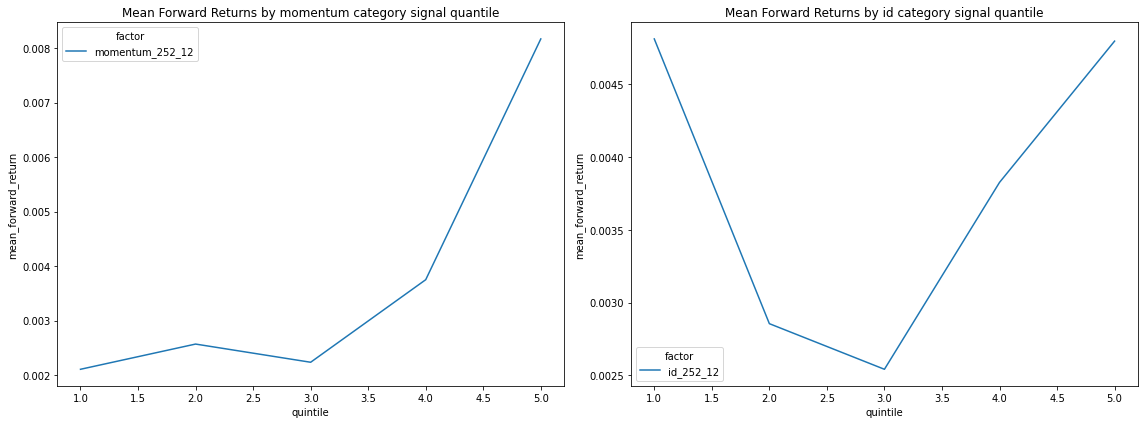

In [32]:
reversal_results_quintile_dict, reversal_summary_quintile_dict = results_quintile_dict["momentum"], summary_quintile_dict["momentum"]

plot_quintiles(reversal_results_quintile_dict, reversal_summary_quintile_dict, "momentum")

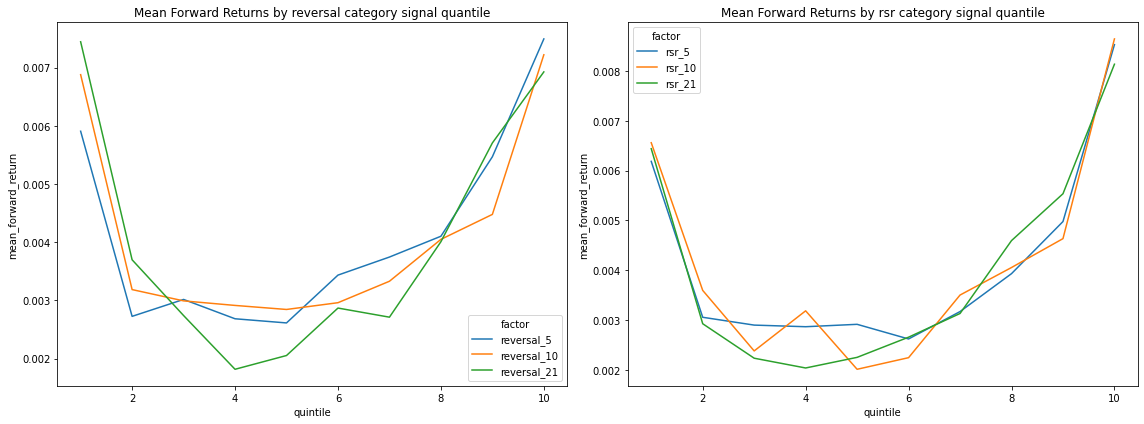

In [38]:
reversal_quintile_dict, reversal_summary_quintile_df = Quintile(returns_df, factors_df_dict["reversal"], 10).run_data()

plot_quintiles(reversal_quintile_dict, reversal_summary_quintile_df, "reversal")

In [21]:
reversal_df = factors_df_dict["reversal"]
reversal_df_factors = reversal_df.columns[2:]
reversal_factors = [col for col in reversal_df_factors if col.startswith("reversal")]
rsr_factors = [col for col in reversal_df_factors if col.startswith("rsr")]

In [22]:
rev_df_correlation = reversal_df[[col for col in reversal_df_factors if col.startswith("reversal")]].corr("spearman")
rsr_df_correlation = reversal_df[[col for col in reversal_df_factors if col.startswith("rsr")]].corr("spearman")

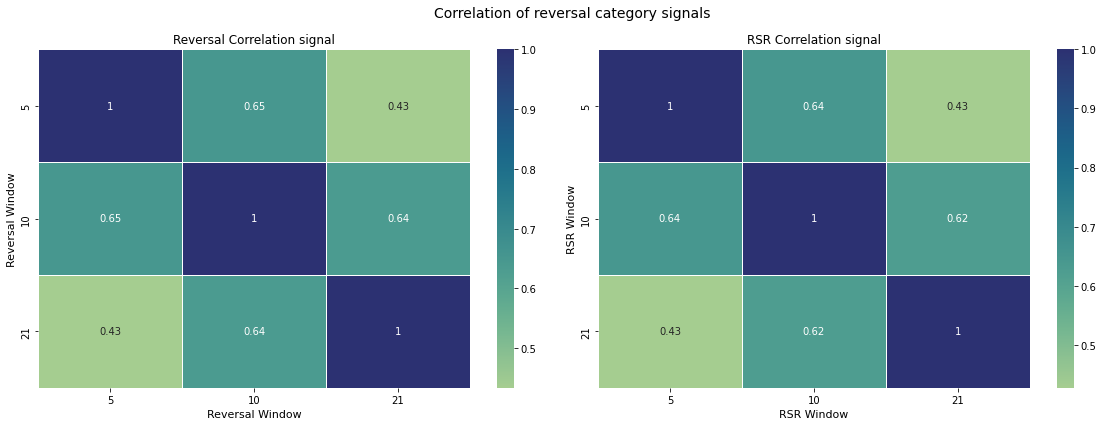

In [27]:
correlation_dfs_dict = {
    "Reversal": rev_df_correlation, 
    "RSR": rsr_df_correlation
}


fig, axs = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Correlation of reversal category signals", fontsize=14)
axs = axs.ravel()
i = 0 
for key, df in correlation_dfs_dict.items(): 
    df.index = [x.split('_')[-1] for x in df.index]
    df.columns = [x.split('_')[-1] for x in df.columns]
    sns.heatmap(
        df, ax=axs[i], cmap="crest", annot=True, linewidths=1
    )
    axs[i].set_title(f"{key} Correlation signal", fontsize=12)
    axs[i].set_xlabel(f"{key} Window", fontsize=11)
    axs[i].set_ylabel(f"{key} Window", fontsize=11)
    i += 1
plt.tight_layout()
plt.show()

### PVO

In [39]:
pvo_results_ic_dict, pvo_summary_ic_df = results_ic_dict["pvo"], summary_ic_dict["pvo"]

In [42]:
pvo_summary_ic_df

,"pvo_((0.01, 0.99), (26, 12))"
ic_ir,0.055447
mean_ic,0.005391
n_periods,1006.000000
positive_ic_rate,0.504970
std_ic,0.097222


In [44]:
plot_ic_timeseries(pvo_results_ic_dict, "pvo")

KeyError: 'pvo'

### Reversal Illiquidity

In [ ]:
IC(returns_df, factors_df_dict["pvo"]).run_data()

In [31]:
reversal_ic_dict["reversal_10"]

{'reversal_5': {...},
 'reversal_10': {...},
 'reversal_21': {...},
 'rsr_5': {...},
 'rsr_10': {...},
 'rsr_21': {...}}

<AxesSubplot:>

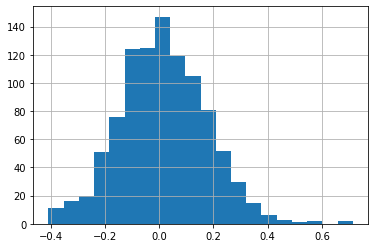

In [16]:
reversal_ic_dict["reversal_21"].hist(bins=20)

In [18]:
IC(returns_df, factors_df_dict["momentum_liquidity"]).run_data()

({'momentum_liquidity_21':           Date                 factor            target        IC
  0   2023-07-13  momentum_liquidity_21  future_return_5d  0.107145
  1   2023-07-14  momentum_liquidity_21  future_return_5d  0.002506
  2   2023-07-17  momentum_liquidity_21  future_return_5d -0.016175
  3   2023-07-18  momentum_liquidity_21  future_return_5d  0.011867
  4   2023-07-19  momentum_liquidity_21  future_return_5d  0.061042
  ..         ...                    ...               ...       ...
  729 2026-05-29  momentum_liquidity_21  future_return_5d -0.059243
  730 2026-06-01  momentum_liquidity_21  future_return_5d -0.145856
  731 2026-06-02  momentum_liquidity_21  future_return_5d -0.261944
  732 2026-06-03  momentum_liquidity_21  future_return_5d -0.287476
  733 2026-06-04  momentum_liquidity_21  future_return_5d -0.228393
  
  [734 rows x 4 columns],
  'momentum_liquidity_63':           Date                 factor            target        IC
  0   2023-07-13  momentum_liquidity_

In [8]:
IC(returns_df, factors_df_dict["pvo"]).run_data()

,"pvo_((0.01, 0.99), (26, 12))"
ic_ir,0.055447
mean_ic,0.005391
n_periods,1006.000000
positive_ic_rate,0.504970
std_ic,0.097222


In [9]:
IC(returns_df, factors_df_dict["reversal"]).run_data()

,reversal_5,reversal_10,reversal_21,rsr_5,rsr_10,rsr_21
mean_ic,0.023775,0.014680,0.015380,0.015893,0.016805,0.019927
std_ic,0.154832,0.159929,0.161706,0.116616,0.116223,0.119392
ic_ir,0.153553,0.091791,0.095111,0.136280,0.144597,0.166901
positive_ic_rate,0.567864,0.517553,0.530426,0.546906,0.566700,0.565923
n_periods,1002.000000,997.000000,986.000000,1002.000000,997.000000,986.000000


In [11]:
IC(returns_df, factors_df_dict["reversal_illiquidity"]).run_data()

,"reversal_illiquidity_(5, 21)","reversal_illiquidity_(5, 63)","reversal_illiquidity_(5, 126)","reversal_illiquidity_(10, 21)","reversal_illiquidity_(10, 63)","reversal_illiquidity_(10, 126)","reversal_illiquidity_(21, 21)","reversal_illiquidity_(21, 63)","reversal_illiquidity_(21, 126)"
mean_ic,0.000906,0.002136,0.004395,-0.005545,-0.003548,-0.000557,-0.002796,-0.003191,-0.001153
std_ic,0.137560,0.138776,0.138489,0.143973,0.145102,0.143113,0.142457,0.145326,0.144678
ic_ir,0.006588,0.015390,0.031733,-0.038513,-0.024449,-0.003893,-0.019629,-0.021957,-0.007972
positive_ic_rate,0.491474,0.494877,0.501059,0.484453,0.483607,0.495763,0.489858,0.495902,0.502119
n_periods,997.000000,976.000000,944.000000,997.000000,976.000000,944.000000,986.000000,976.000000,944.000000
